# GP Training

$$
\text{GP} = \{R\ |\ T_{H,1},\ T_{S,1},\ u_1\}
$$

---

## Setup

In [100]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.interpolate import interp1d

In [101]:
modelname = "tclab_residual_withZeros"
BUFFER_ZEROS = True  # boolean to add instances of R=0 at (Th1,Ts1,u1)=(0,0,0)

In [102]:
data = pd.read_csv(os.path.join(dir, "data", "step_tests.csv"))
alpha = 0.00016 # watts / (units P1 * percent U1)
P1 = 200 # P1 units

tvec = data["Time"].values
Ts1 = data["T1"].values - data["T1"][0]  # minus Tamb
u1 = data["Q1"].values

## Linear Regression:

- see https://dowlinglab.github.io/pyomo-doe/notebooks/numpy_simulation.html

In [103]:
import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('lines', linewidth=3)

In [104]:
# Initial point:
param0 = [0.05,  # Ua, watts/deg C
          0.05,  # Ub, watts/deg C
        #   1 / 5,     # 1/CpH, 1/(joules/deg C)
          5,     # CpH, joules/deg C
        #   1 / 1]     # 1/CpS, 1/(joules/deg C)
          1]     # CpS, joules/deg C

# Solve model:

u1_interp = interp1d(tvec, u1, kind='previous')

def tclab_model(param):
    # Ua, Ub, inv_CpH, inv_CpS = param  # adjustable parameters
    Ua, Ub, CpH, CpS = param  # adjustable parameters

    def deriv(t, y):  # two-state model
        T1H, T1S = y
        # dT1H = (-Ua * T1H + Ub * (T1S - T1H) + alpha * P1 * u1_interp(t)) * inv_CpH
        dT1H = (-Ua * T1H + Ub * (T1S - T1H) + alpha * P1 * u1_interp(t)) / CpH
        # dT1S = Ub * (T1H - T1S) * inv_CpS
        dT1S = Ub * (T1H - T1S) / CpS
        return [dT1H, dT1S]
    
    soln = solve_ivp(deriv, [tvec[0], tvec[-1]], [0, 0], t_eval=tvec)  # model solution
    
    pred = pd.DataFrame()  # dataframe with predictions
    pred["Time"] = tvec
    pred["TH1"] = soln.y[0]
    pred["TS1"] = soln.y[1]
    pred["Q1"] = u1_interp(tvec)

    return pred

# Regress model
def residuals(param):
    pred = tclab_model(param)
    return pred["TS1"] - Ts1

# Set bounds (non-negative):
bnds = ([0.0, 0.0, 0.0, 0.0], [np.inf, np.inf, np.inf, np.inf])

# Perform least squares nonlinear regression:
nl_results = least_squares(residuals, param0, bounds=bnds, method='trf', verbose=2, loss="arctan")
param = nl_results.x

# ========================================

# Ua, Ub, inv_CpH, inv_CpS = param
# CpH = 1 / inv_CpH
# CpS = 1 / inv_CpS

Ua, Ub, CpH, CpS = param

Ts1_p = tclab_model(param)["TS1"].values
Th1_p = tclab_model(param)["TH1"].values

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         5.5405e+02                                    6.97e+04    
       1              6         4.3414e+02      1.20e+02       9.07e-03       2.30e+04    
       2              7         3.6673e+02      6.74e+01       3.80e-02       6.91e+03    
       3              8         3.2434e+02      4.24e+01       3.99e-02       1.07e+04    
       4              9         2.8035e+02      4.40e+01       8.08e-02       6.86e+03    
       5             10         2.5676e+02      2.36e+01       1.59e-01       2.40e+03    
       6             11         1.4862e+02      1.08e+02       1.59e-01       2.52e+03    
       7             12         1.3887e+02      9.75e+00       2.17e-01       1.48e+03    
       8             18         1.3714e+02      1.73e+00       8.14e-05       1.08e+03    
       9             20         1.3651e+02      6.38e-01       3.65e-05       2.38e+03    

In [105]:
print(f"Ua  = {Ua}\nUb  = {Ub}\nCpH = {CpH}\nCpS = {CpS}")

Ua  = 0.052384291033157684
Ub  = 0.060521133829919416
CpH = 5.568800661406845
CpS = 1.2773885658179458


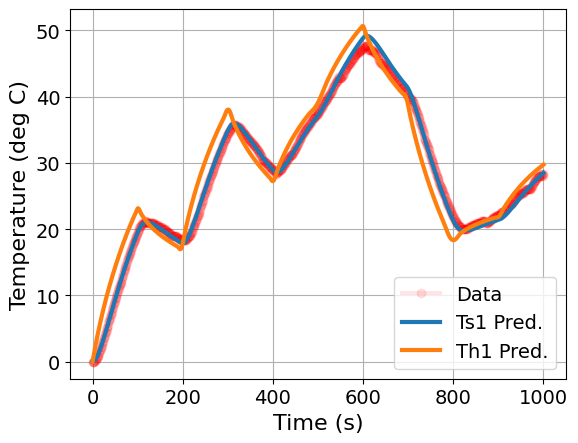

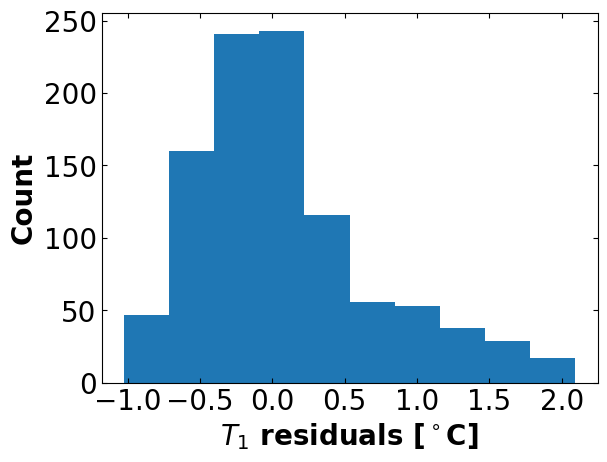

Estimated standard deviation of residuals: 0.631 deg C

Covariance of p = [Ua, Ub, inv_CpH, inv_CpS]
[[ 9.51265994e-09  9.06683190e-14 -2.19926484e-06  3.31845134e-07]
 [ 9.06683190e-14  1.22929111e-18 -2.42576033e-11  3.11998491e-12]
 [-2.19926484e-06 -2.42576033e-11  1.30084289e-03 -1.96162406e-04]
 [ 3.31845134e-07  3.11998491e-12 -1.96162406e-04  3.10986809e-05]]

Correlation matrix
[[ 1.          0.83845007 -0.62519302  0.6101175 ]
 [ 0.83845007  1.         -0.60660795  0.50460801]
 [-0.62519302 -0.60660795  1.         -0.97528686]
 [ 0.6101175   0.50460801 -0.97528686  1.        ]]


In [106]:
def covariance_to_correlation(cov):
    '''Convert covariance matrix into correlation matrix

    Argument:
        cov: covariance matrix

    Returns:
        cor: correlation matrix

    '''

    # Copy matrix
    cor = cov.copy()

    # Get number of rows
    n = cor.shape[0]

    # Loop over rows
    for r in range(n):
        # Loop over columns
        for c in range(n):
            # Scale element
            cor[r, c] = cor[r, c] / np.sqrt(cov[r, r] * cov[c, c])

    return cor


plt.plot(tvec, Ts1, marker='o', color='red', alpha=0.1)
plt.plot(tvec, Ts1_p, linewidth=3)
plt.plot(tvec, Th1_p, linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Temperature (deg C)")
plt.legend(["Data", "Ts1 Pred.", "Th1 Pred."])
plt.grid()
plt.show()

# plot the residuals
r = residuals(nl_results.x)

# define font size
fs = 20

# plot data
plt.hist(r)
plt.xlabel("$T_1$ residuals [$^\circ{}$C]", fontsize=fs, fontweight='bold')
plt.ylabel("Count", fontsize=fs, fontweight='bold')

# define tick size
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.tick_params(direction="in", top=True, right=True)

# finish plot
plt.show()

# Estimate covariance and correlation of fitted parameters

# Estimate covariance of residuals
var_residuals = r.T @ r / (len(r) - len(nl_results.x))
print(
    "Estimated standard deviation of residuals:",
    round(np.sqrt(var_residuals), 3),
    "deg C",
)

# Estimate covariance of fitted parameters
cov_p = var_residuals * np.linalg.inv(nl_results.jac.T @ nl_results.jac)

print("\nCovariance of p = [Ua, Ub, inv_CpH, inv_CpS]")
print(cov_p)

print("\nCorrelation matrix")
print(covariance_to_correlation(cov_p))

## FoKL Model

In [107]:
# Residual:
R = Ts1 - Ts1_p

# Add buffer:
buffer = 500  # number of instances added to help GP nail R=0 at (Th1,Ts1,u1)=(0,0,0)

# Train GP on two-state model predictions (i.e., un-corrected Th1, Ts1) and measured u1:
pathname = os.path.join(dir, "models", modelname)
try:
    GP = FoKLRoutines.load(pathname)
    print("Model already trained. Rename 'modelname' to train a new model.")
except Exception as exception:
    GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, way3=True)
    pillow=[[0.01, 0.05], [0.01, 0.05], [0, 0]]

    if BUFFER_ZEROS:
        GP.fit([np.concatenate([np.zeros(buffer), Th1_p]), 
                np.concatenate([np.zeros(buffer), Ts1_p]), 
                np.concatenate([np.zeros(buffer), u1])], 
                np.concatenate([np.zeros(buffer), R]), 
                clean=True, pillow=pillow)
    else:
        GP.fit([Th1_p, Ts1_p, u1], R, clean=True, pillow=pillow)
    
    GP.save(pathname)

[1, -855.2176122714422]
[2, -2145.7113814663526]
[2, -2261.5424550117173]
[3, -2313.0567209165815]
[3, -3281.82624935503]
[3, -3416.208653672431]
[4, -3675.9947851426905]
[4, -3826.5168361090946]
[4, -3938.091624940168]
[4, -4061.609322086302]
[5, -4190.887151821218]
[5, -4240.730172978177]
[5, -4686.937915728953]
[5, -4795.936442197765]
[5, -4830.449046119778]
[6, -4824.032092803792]
[6, -4992.369434936597]
[6, -4965.367194069212]
[6, -5080.441465965996]
[6, -4929.397864240359]
[6, -4792.59225719726]
[7, -5182.819548305814]
[7, -5082.544805925685]
[7, -5203.473909709893]
[7, -1172.7971957978084]
[7, -5279.87990363893]
[7, -4009.344742717267]
[7, -3218.9831801195005]
[8, -733.3847314131413]


# NOTES

- *tclab_optimization.ipynb* found the Pyomo model with the GP correction only works if ```CpH, CpS``` are found directly in the linear regression instead of ```inv_CpH, inv_CpS```; it is not understood why
- ```pillow=[[0.01, 0.05], [0.01, 0.05], [0, 0]]``` works though others may work too